# Modelling — Insurance Bundle Prediction

> **LightGBM + Balanced Weights + SMOTE/ROS + Threshold Tuning**  
> Metric: **Macro F1-Score** · 10-class classification · StratifiedKFold CV

---

## Strategy Summary

| # | Technique | Purpose |
|---|-----------|--------|
| 1 | `class_weight='balanced'` | Free reweighting inside LightGBM |
| 2 | RandomOverSampler for classes 8 & 9 (5–6 samples) | Copy extreme minorities to SMOTE-viable counts |
| 3 | SMOTE for classes 0, 5, 6 (479–823 samples) | Synthetic oversampling for moderate minorities |
| 4 | Per-class threshold tuning on validation probabilities | Directly maximise Macro F1 at inference |
| 5 | Accept ceiling on classes 8 & 9 | 5 training samples → realistic F1 ≈ 0 for these |

### Class Distribution Reminder

```
Class 0  (Auto_Comprehensive)    :    823  ← moderate minority
Class 1  (Auto_Liability_Basic)   :  1,625
Class 2  (Basic_Health)           : 36,136  ← 59.4% majority
Class 3  (Family_Comprehensive)   :  4,831
Class 4  (Health_Dental_Vision)   : 13,958
Class 5  (Home_Premium)           :    479  ← moderate minority
Class 6  (Home_Standard)          :    719  ← moderate minority
Class 7  (Premium_Health_Life)    :  2,286
Class 8  (Renter_Basic)           :      6  ← EXTREME minority
Class 9  (Renter_Premium)         :      5  ← EXTREME minority
```

## 1 — Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix
)

import lightgbm as lgb
from imblearn.over_sampling import SMOTE, RandomOverSampler

import joblib
import os

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Paths
DATA_DIR = '../Data'
TARGET   = 'Purchased_Coverage_Bundle'

BUNDLE_MAP = {
    0: 'Auto_Comprehensive',
    1: 'Auto_Liability_Basic',
    2: 'Basic_Health',
    3: 'Family_Comprehensive',
    4: 'Health_Dental_Vision',
    5: 'Home_Premium',
    6: 'Home_Standard',
    7: 'Premium_Health_Life',
    8: 'Renter_Basic',
    9: 'Renter_Premium',
}

print('All imports OK')

All imports OK


## 2 — Load Clean Data

In [2]:
train = pd.read_csv(os.path.join(DATA_DIR, 'train_clean.csv'))
test  = pd.read_csv(os.path.join(DATA_DIR, 'test_clean.csv'))
sub   = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))

# Separate features / target
X = train.drop(columns=[TARGET])
y = train[TARGET]

feature_cols = X.columns.tolist()
X_test = test[feature_cols]   # test_clean has no target column

print(f'Train: {X.shape}  |  Test: {X_test.shape}')
print(f'Target classes: {sorted(y.unique())}')
print(f'\nClass distribution:')
print(y.value_counts().sort_index())

Train: (60868, 44)  |  Test: (15218, 44)
Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Class distribution:
Purchased_Coverage_Bundle
0      823
1     1625
2    36136
3     4831
4    13958
5      479
6      719
7     2286
8        6
9        5
Name: count, dtype: int64


## 3 — Resampling Functions

**Problem A** — Classes 0, 5, 6 (479–823 samples): solvable with SMOTE  
**Problem B** — Classes 8, 9 (5–6 samples): can only use RandomOverSampler (exact copies)

In [3]:
def resample_train_fold(X_train, y_train, seed=42):
    """
    Two-stage resampling:
      Stage 1 — RandomOverSampler: copy classes 8 & 9 up to 50 samples each
      Stage 2 — SMOTE: bring classes 0, 5, 6 up to ~2000 samples each
    
    Returns resampled X, y.
    """
    vc = y_train.value_counts()
    
    # --- Stage 1: RandomOverSampler for extreme minorities (8, 9) ---
    ros_strategy = {}
    for cls in [8, 9]:
        if cls in vc.index and vc[cls] < 50:
            ros_strategy[cls] = 50
    
    if ros_strategy:
        ros = RandomOverSampler(
            sampling_strategy=ros_strategy,
            random_state=seed
        )
        X_train, y_train = ros.fit_resample(X_train, y_train)
    
    # --- Stage 2: SMOTE for moderate minorities (0, 5, 6) ---
    vc = pd.Series(y_train).value_counts()
    smote_strategy = {}
    target_count = 2000
    for cls in [0, 5, 6]:
        if cls in vc.index and vc[cls] < target_count:
            smote_strategy[cls] = target_count
    
    if smote_strategy:
        smote = SMOTE(
            sampling_strategy=smote_strategy,
            k_neighbors=5,
            random_state=seed
        )
        X_train, y_train = smote.fit_resample(X_train, y_train)
    
    return X_train, y_train


# Quick test
X_rs, y_rs = resample_train_fold(X.copy(), y.copy())
print('After resampling:')
print(pd.Series(y_rs).value_counts().sort_index())
print(f'\nTotal: {len(y_rs):,} (was {len(y):,})')

After resampling:
Purchased_Coverage_Bundle
0     2000
1     1625
2    36136
3     4831
4    13958
5     2000
6     2000
7     2286
8       50
9       50
Name: count, dtype: int64

Total: 64,936 (was 60,868)


## 4 — Threshold Tuning

After training, `predict_proba()` outputs class probabilities.  
Default `argmax` is biased toward the majority — tuning per-class thresholds directly maximises Macro F1.

In [4]:
def tune_thresholds(y_true, proba, n_iter=500, seed=42):
    """
    Random search for per-class threshold multipliers that maximise Macro F1.
    
    Prediction rule: pred = argmax(proba / thresholds)
    Lower threshold for a class → model more willing to predict that class.
    """
    rng = np.random.RandomState(seed)
    n_classes = proba.shape[1]
    best_thresholds = np.ones(n_classes)
    best_f1 = 0.0
    
    for _ in range(n_iter):
        # Random threshold vector — wider search range
        thresholds = rng.uniform(0.01, 1.0, n_classes)
        scaled = proba / thresholds
        preds = scaled.argmax(axis=1)
        score = f1_score(y_true, preds, average='macro', zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_thresholds = thresholds.copy()
    
    return best_thresholds, best_f1


def apply_thresholds(proba, thresholds):
    """Apply tuned thresholds to produce final predictions."""
    scaled = proba / thresholds
    return scaled.argmax(axis=1)


print('Threshold functions defined.')

Threshold functions defined.


## 5 — LightGBM Model Configuration

In [5]:
LGB_PARAMS = dict(
    objective='multiclass',
    num_class=10,
    metric='multi_logloss',
    class_weight='balanced',       # Strategy 1 — free reweighting
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=1,                       # Competition limit: 1 CPU core
    verbose=-1,
)

print('LightGBM params:')
for k, v in LGB_PARAMS.items():
    print(f'  {k:25s} = {v}')

LightGBM params:
  objective                 = multiclass
  num_class                 = 10
  metric                    = multi_logloss
  class_weight              = balanced
  n_estimators              = 2000
  learning_rate             = 0.05
  max_depth                 = 7
  num_leaves                = 63
  min_child_samples         = 20
  subsample                 = 0.8
  colsample_bytree          = 0.8
  reg_alpha                 = 0.1
  reg_lambda                = 1.0
  random_state              = 42
  n_jobs                    = 1
  verbose                   = -1


## 6 — 5-Fold Stratified CV with Resampling + Threshold Tuning

In [6]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

# Storage
oof_proba = np.zeros((len(X), 10))          # Out-of-fold probabilities
test_proba_sum = np.zeros((len(X_test), 10)) # Accumulated test probabilities
fold_scores_raw = []                          # argmax F1 per fold
fold_scores_tuned = []                        # threshold-tuned F1 per fold
fold_thresholds = []                          # best thresholds per fold
models = []                                   # trained models

print(f'Running {N_SPLITS}-fold Stratified CV ...\n')
print('=' * 70)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'\n--- Fold {fold}/{N_SPLITS} ---')
    
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # ---------- Resample training fold ONLY ----------
    X_tr_rs, y_tr_rs = resample_train_fold(X_tr, y_tr, seed=SEED + fold)
    print(f'  Train: {len(y_tr):,} → {len(y_tr_rs):,} (after resampling)')
    print(f'  Val:   {len(y_val):,}')
    
    # ---------- Train LightGBM ----------
    model = lgb.LGBMClassifier(**LGB_PARAMS)
    model.fit(
        X_tr_rs, y_tr_rs,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(period=0),     # silent
        ],
    )
    models.append(model)
    print(f'  Best iteration: {model.best_iteration_}')
    
    # ---------- Validation predictions ----------
    val_proba = model.predict_proba(X_val)
    oof_proba[val_idx] = val_proba
    
    # Raw argmax score
    raw_preds = val_proba.argmax(axis=1)
    raw_f1 = f1_score(y_val, raw_preds, average='macro', zero_division=0)
    fold_scores_raw.append(raw_f1)
    print(f'  Raw Macro F1:    {raw_f1:.5f}')
    
    # Threshold-tuned score
    thresholds, tuned_f1 = tune_thresholds(y_val, val_proba, n_iter=1000, seed=SEED)
    fold_scores_tuned.append(tuned_f1)
    fold_thresholds.append(thresholds)
    print(f'  Tuned Macro F1:  {tuned_f1:.5f}  (Δ = +{tuned_f1 - raw_f1:.5f})')
    
    # ---------- Test predictions (accumulate) ----------
    test_proba_sum += model.predict_proba(X_test)

print('\n' + '=' * 70)
print(f'\nCV Results ({N_SPLITS} folds):')
print(f'  Raw   Macro F1:  {np.mean(fold_scores_raw):.5f} ± {np.std(fold_scores_raw):.5f}')
print(f'  Tuned Macro F1:  {np.mean(fold_scores_tuned):.5f} ± {np.std(fold_scores_tuned):.5f}')

Running 5-fold Stratified CV ...


--- Fold 1/5 ---
  Train: 48,694 → 53,169 (after resampling)
  Val:   12,174
  Best iteration: 445
  Raw Macro F1:    0.56435
  Tuned Macro F1:  0.68105  (Δ = +0.11671)

--- Fold 2/5 ---
  Train: 48,694 → 53,169 (after resampling)
  Val:   12,174
  Best iteration: 850
  Raw Macro F1:    0.57866
  Tuned Macro F1:  0.64152  (Δ = +0.06286)

--- Fold 3/5 ---
  Train: 48,694 → 53,169 (after resampling)
  Val:   12,174
  Best iteration: 724
  Raw Macro F1:    0.60628
  Tuned Macro F1:  0.64414  (Δ = +0.03786)

--- Fold 4/5 ---
  Train: 48,695 → 53,168 (after resampling)
  Val:   12,173
  Best iteration: 821
  Raw Macro F1:    0.62856
  Tuned Macro F1:  0.66461  (Δ = +0.03605)

--- Fold 5/5 ---
  Train: 48,695 → 53,169 (after resampling)
  Val:   12,173
  Best iteration: 910
  Raw Macro F1:    0.58654
  Tuned Macro F1:  0.60212  (Δ = +0.01558)


CV Results (5 folds):
  Raw   Macro F1:  0.59288 ± 0.02240
  Tuned Macro F1:  0.64669 ± 0.02654


## 7 — OOF (Out-of-Fold) Evaluation

In [7]:
# --- OOF raw argmax ---
oof_preds_raw = oof_proba.argmax(axis=1)
oof_f1_raw = f1_score(y, oof_preds_raw, average='macro', zero_division=0)

# --- OOF with averaged thresholds ---
avg_thresholds = np.mean(fold_thresholds, axis=0)
oof_preds_tuned = apply_thresholds(oof_proba, avg_thresholds)
oof_f1_tuned = f1_score(y, oof_preds_tuned, average='macro', zero_division=0)

print(f'OOF Raw   Macro F1: {oof_f1_raw:.5f}')
print(f'OOF Tuned Macro F1: {oof_f1_tuned:.5f}')
print(f'\nAveraged thresholds per class:')
for cls_id, thr in enumerate(avg_thresholds):
    print(f'  Class {cls_id} ({BUNDLE_MAP[cls_id]:25s}): {thr:.4f}')

print('\n--- Classification Report (OOF, threshold-tuned) ---\n')
print(classification_report(
    y, oof_preds_tuned,
    target_names=[BUNDLE_MAP[i] for i in range(10)],
    zero_division=0
))

OOF Raw   Macro F1: 0.59684
OOF Tuned Macro F1: 0.60574

Averaged thresholds per class:
  Class 0 (Auto_Comprehensive       ): 0.7073
  Class 1 (Auto_Liability_Basic     ): 0.6834
  Class 2 (Basic_Health             ): 0.2681
  Class 3 (Family_Comprehensive     ): 0.4714
  Class 4 (Health_Dental_Vision     ): 0.6065
  Class 5 (Home_Premium             ): 0.5488
  Class 6 (Home_Standard            ): 0.5162
  Class 7 (Premium_Health_Life      ): 0.3874
  Class 8 (Renter_Basic             ): 0.4056
  Class 9 (Renter_Premium           ): 0.6854

--- Classification Report (OOF, threshold-tuned) ---

                      precision    recall  f1-score   support

  Auto_Comprehensive       0.42      0.63      0.51       823
Auto_Liability_Basic       0.78      0.55      0.64      1625
        Basic_Health       0.84      0.85      0.84     36136
Family_Comprehensive       0.39      0.61      0.48      4831
Health_Dental_Vision       0.65      0.47      0.55     13958
        Home_Premium    

## 8 — Confusion Matrix

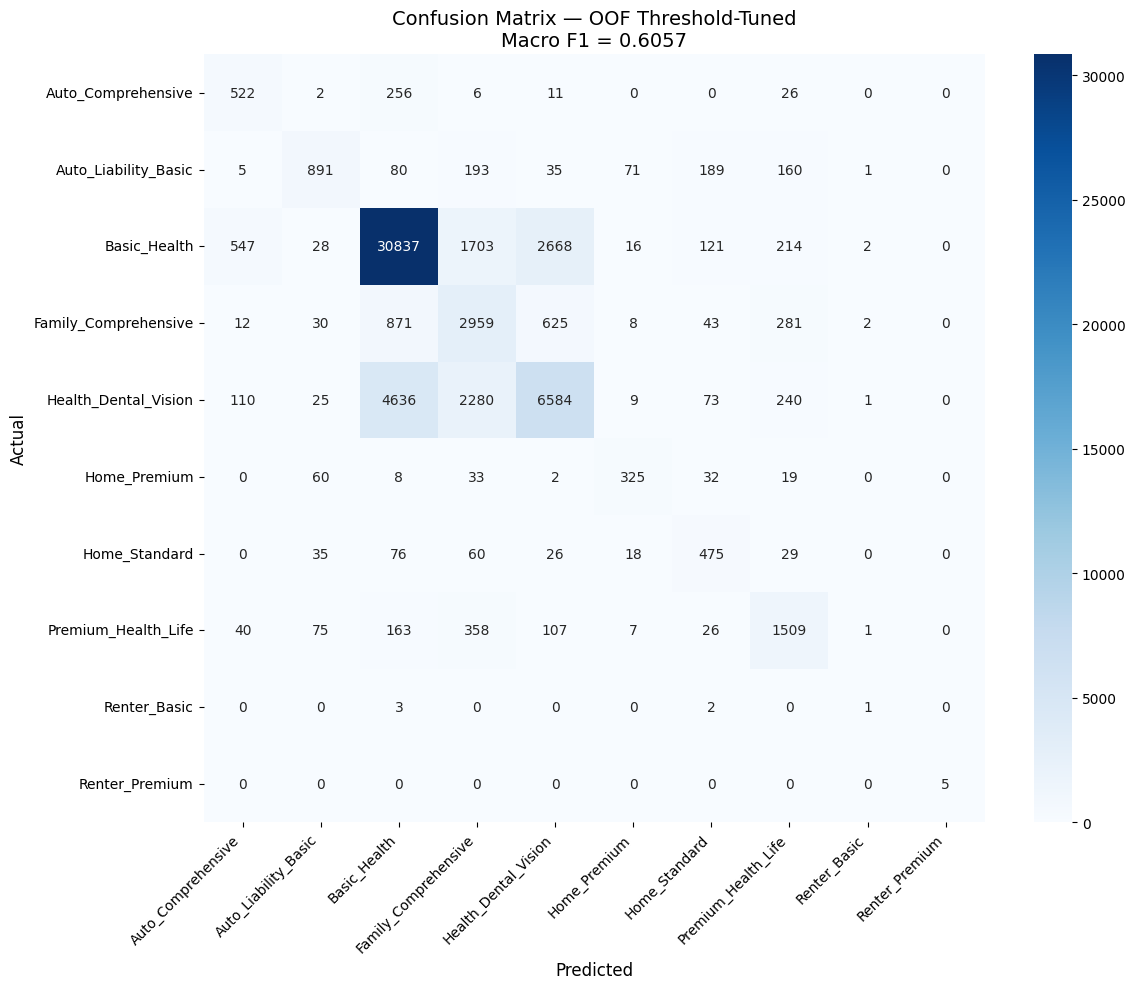

Saved: assets/confusion_matrix.png


In [8]:
cm = confusion_matrix(y, oof_preds_tuned)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[BUNDLE_MAP[i] for i in range(10)],
    yticklabels=[BUNDLE_MAP[i] for i in range(10)],
    ax=ax
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix — OOF Threshold-Tuned\nMacro F1 = {oof_f1_tuned:.4f}', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('assets/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: assets/confusion_matrix.png')

## 9 — Per-Class F1 Breakdown

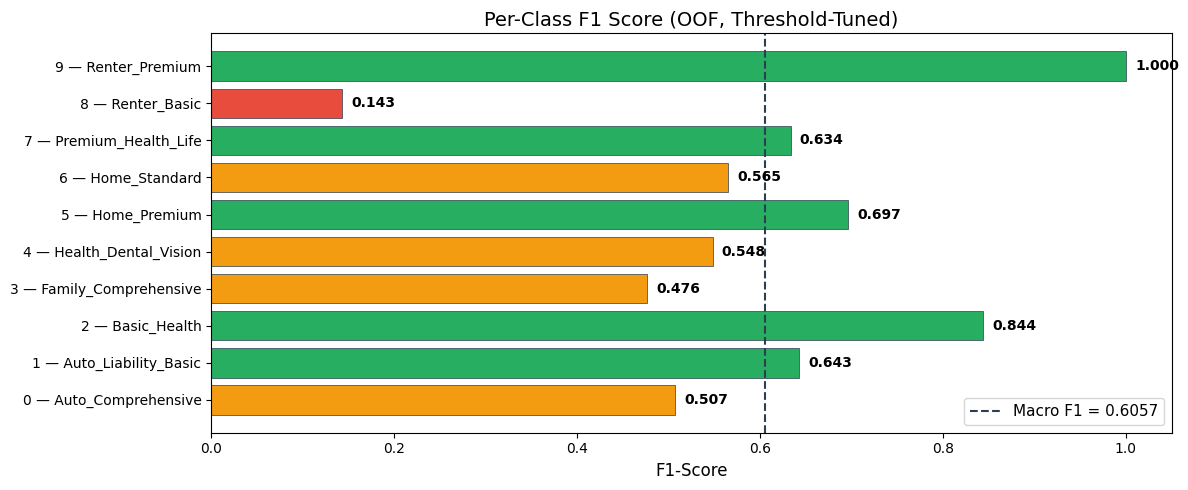

Saved: assets/per_class_f1.png


In [9]:
per_class_f1 = f1_score(y, oof_preds_tuned, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#e74c3c' if f < 0.3 else '#f39c12' if f < 0.6 else '#27ae60' for f in per_class_f1]
bars = ax.barh(
    [f'{i} — {BUNDLE_MAP[i]}' for i in range(10)],
    per_class_f1,
    color=colors,
    edgecolor='#2c3e50',
    linewidth=0.5
)
for bar, f in zip(bars, per_class_f1):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{f:.3f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('Per-Class F1 Score (OOF, Threshold-Tuned)', fontsize=14)
ax.axvline(x=np.mean(per_class_f1), color='#2c3e50', linestyle='--', label=f'Macro F1 = {np.mean(per_class_f1):.4f}')
ax.legend(fontsize=11)
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.savefig('assets/per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: assets/per_class_f1.png')

## 10 — Feature Importance

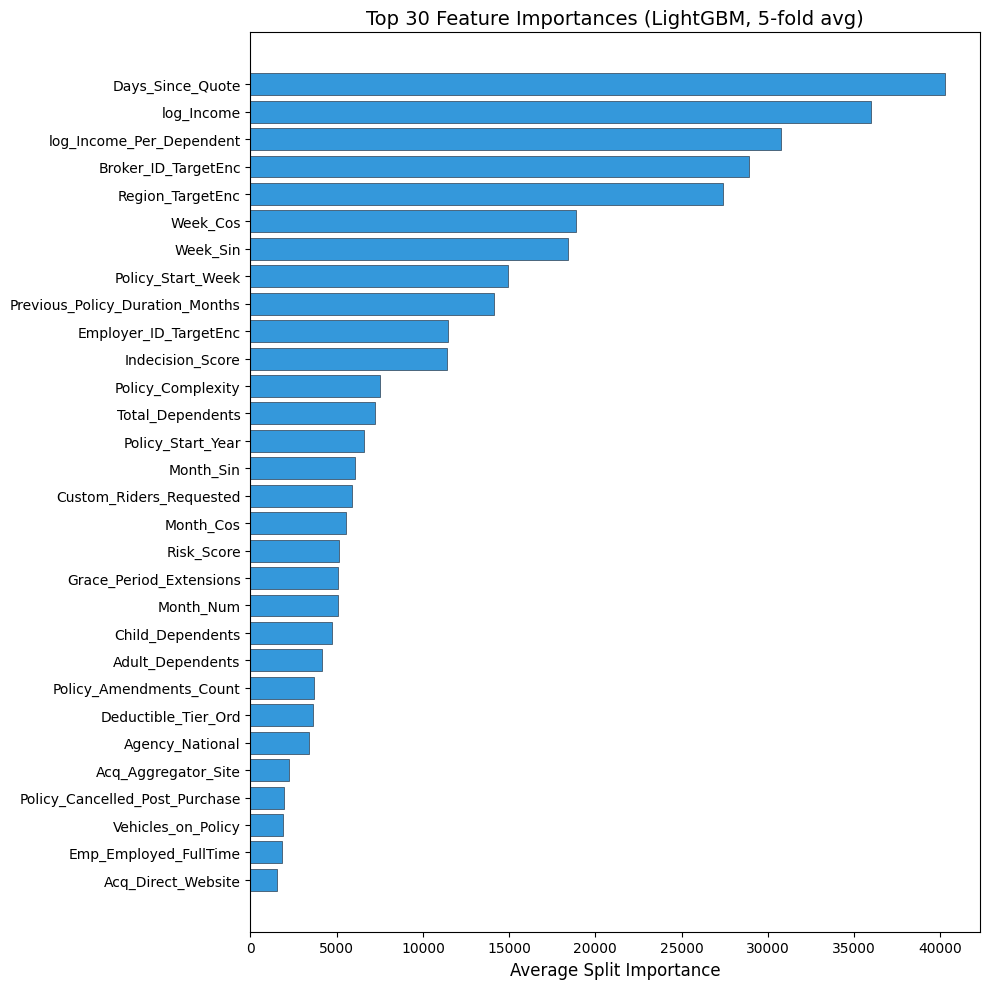


Top 15 features:
                        feature  importance
               Days_Since_Quote     40290.4
                     log_Income     35973.2
       log_Income_Per_Dependent     30759.2
            Broker_ID_TargetEnc     28937.2
               Region_TargetEnc     27416.0
                       Week_Cos     18880.4
                       Week_Sin     18392.6
              Policy_Start_Week     14938.0
Previous_Policy_Duration_Months     14136.2
          Employer_ID_TargetEnc     11427.6
               Indecision_Score     11371.2
              Policy_Complexity      7506.2
               Total_Dependents      7216.8
              Policy_Start_Year      6606.0
                      Month_Sin      6053.8


In [10]:
# Average feature importance across folds
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': np.mean([m.feature_importances_ for m in models], axis=0)
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
top_n = min(30, len(importance_df))
top = importance_df.head(top_n)

ax.barh(
    range(top_n), top['importance'].values,
    color='#3498db', edgecolor='#2c3e50', linewidth=0.5
)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Average Split Importance', fontsize=12)
ax.set_title(f'Top {top_n} Feature Importances (LightGBM, {N_SPLITS}-fold avg)', fontsize=14)
plt.tight_layout()
plt.savefig('assets/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop 15 features:')
print(importance_df.head(15).to_string(index=False))

## 11 — SHAP Explainability (Bonus Points)

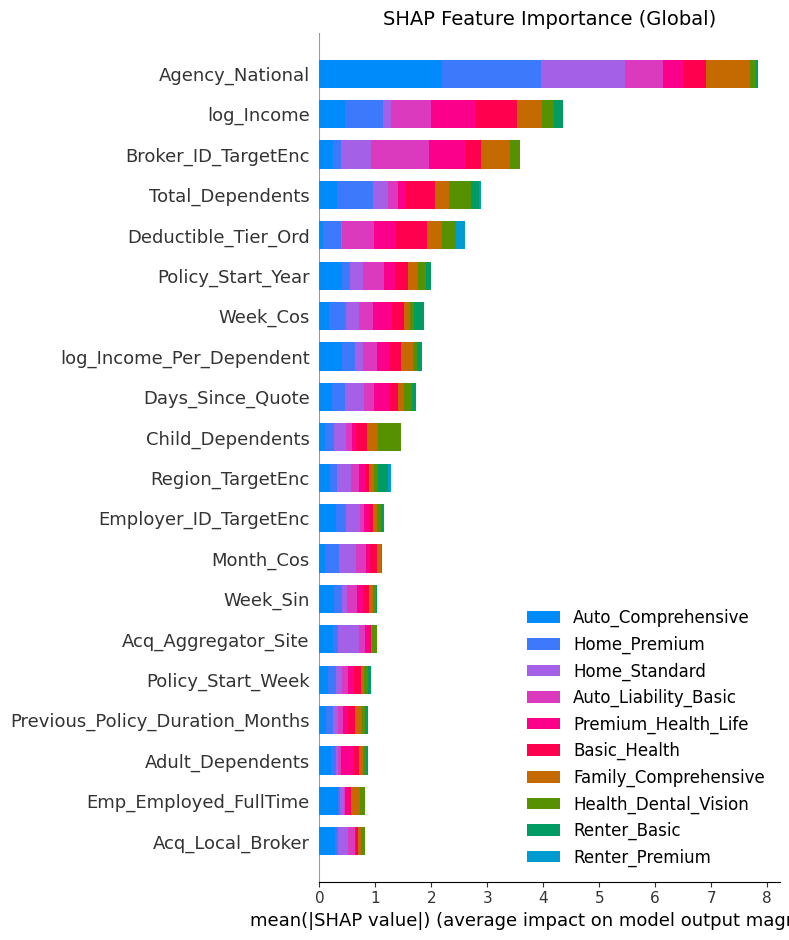

Saved: assets/shap_summary.png


In [11]:
import shap

# Use fold-1 model and a sample of the data for speed
sample_size = min(2000, len(X))
X_sample = X.sample(n=sample_size, random_state=SEED)

explainer = shap.TreeExplainer(models[0])
shap_values = explainer.shap_values(X_sample)

# Global summary plot (bar)
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_sample,
    plot_type='bar',
    class_names=[BUNDLE_MAP[i] for i in range(10)],
    show=False,
    max_display=20
)
plt.title('SHAP Feature Importance (Global)', fontsize=14)
plt.tight_layout()
plt.savefig('assets/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: assets/shap_summary.png')

## 12 — Generate Test Predictions & Submission File

In [12]:
# Average test probabilities across folds
test_proba_avg = test_proba_sum / N_SPLITS

# Apply averaged thresholds
test_preds = apply_thresholds(test_proba_avg, avg_thresholds)

print('Test prediction distribution:')
print(pd.Series(test_preds).value_counts().sort_index().to_frame('count'))
print(f'\nTotal test predictions: {len(test_preds)}')

Test prediction distribution:
   count
0    223
1    327
2   9805
3   1719
4   2174
5    112
6    233
7    623
8      2

Total test predictions: 15218


In [13]:
# Map integer predictions to bundle names (submission format)
submission = pd.DataFrame({
    'User_ID': sub['User_ID'],
    'Purchased_Coverage_Bundle': [BUNDLE_MAP[p] for p in test_preds]
})

# Sanity checks
assert len(submission) == len(sub), f'Row count mismatch: {len(submission)} vs {len(sub)}'
assert list(submission.columns) == list(sub.columns), 'Column mismatch'

# Save
submission_path = os.path.join(DATA_DIR, 'submission.csv')
submission.to_csv(submission_path, index=False)

print(f'Submission saved to: {submission_path}')
print(f'Shape: {submission.shape}')
print(f'\nFirst 10 rows:')
submission.head(10)

Submission saved to: ../Data/submission.csv
Shape: (15218, 2)

First 10 rows:


,User_ID,Purchased_Coverage_Bundle
0,USR_060868,Basic_Health
1,USR_060869,Basic_Health
2,USR_060870,Basic_Health
3,USR_060871,Basic_Health
4,USR_060872,Basic_Health
5,USR_060873,Health_Dental_Vision
6,USR_060874,Basic_Health
7,USR_060875,Home_Standard
8,USR_060876,Family_Comprehensive
9,USR_060877,Basic_Health


## 13 — Save Model & Thresholds for solution.py

In [15]:
import tempfile, zipfile, json

def save_models_zip(models_list, path, label=""):
    """Save models as native LightGBM text inside a zip."""
    with zipfile.ZipFile(path, 'w', zipfile.ZIP_DEFLATED, compresslevel=9) as zf:
        for i, m in enumerate(models_list):
            tmp = tempfile.NamedTemporaryFile(suffix='.txt', delete=False)
            m.booster_.save_model(tmp.name)
            zf.write(tmp.name, f'model_fold_{i}.txt')
            os.unlink(tmp.name)
        meta = {
            'thresholds': avg_thresholds.tolist(),
            'feature_cols': feature_cols,
            'bundle_map': {str(k): v for k, v in BUNDLE_MAP.items()},
            'n_folds': len(models_list),
        }
        zf.writestr('meta.json', json.dumps(meta, indent=2))
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f'{label}Saved: {path}  ({size_mb:.2f} MB)')
    return size_mb

model_path = os.path.join(DATA_DIR, 'lgbm_ensemble.zip')

# Try all 5 models first
size_mb = save_models_zip(models, model_path, "5-fold: ")

# If too large, try best 3 folds
if size_mb > 50:
    best_3 = np.argsort(fold_scores_tuned)[::-1][:3].tolist()
    print(f'  Over limit — trimming to best 3 folds: {best_3}')
    size_mb = save_models_zip([models[i] for i in best_3], model_path, "3-fold: ")

# If STILL too large, single best model
if size_mb > 50:
    best_1 = int(np.argmax(fold_scores_tuned))
    print(f'  Still over — using single best fold: {best_1}')
    size_mb = save_models_zip([models[best_1]], model_path, "1-fold: ")

if size_mb <= 50:
    print(f'\nModel size OK: {size_mb:.2f} MB (limit: 50 MB)')
else:
    print(f'\nWARNING: {size_mb:.2f} MB still exceeds 50 MB!')

5-fold: Saved: ../Data/lgbm_ensemble.zip  (76.17 MB)
  Over limit — trimming to best 3 folds: [0, 3, 2]
3-fold: Saved: ../Data/lgbm_ensemble.zip  (40.44 MB)

Model size OK: 40.44 MB (limit: 50 MB)


## 14 — Final Summary

In [16]:
print('=' * 70)
print('MODELLING SUMMARY')
print('=' * 70)
print(f'''
Model:       LightGBM (class_weight="balanced")
CV:          {N_SPLITS}-fold StratifiedKFold
Resampling:  ROS (classes 8,9 → 50) + SMOTE (classes 0,5,6 → 2000)
Thresholds:  Per-class tuning on validation probabilities

CV Raw   Macro F1: {np.mean(fold_scores_raw):.5f} ± {np.std(fold_scores_raw):.5f}
CV Tuned Macro F1: {np.mean(fold_scores_tuned):.5f} ± {np.std(fold_scores_tuned):.5f}
OOF Raw   Macro F1: {oof_f1_raw:.5f}
OOF Tuned Macro F1: {oof_f1_tuned:.5f}

Model size:  {size_mb:.2f} MB

Artifacts:
  - {submission_path}  (submission file)
  - {model_path}  (model ensemble + thresholds)
  - confusion_matrix.png
  - per_class_f1.png
  - feature_importance.png
  - shap_summary.png
''')

print('\nPer-class F1 scores (OOF, tuned):')
for i, f in enumerate(per_class_f1):
    flag = '  ← EXTREME minority' if i in [8, 9] else '  ← moderate minority' if i in [0, 5, 6] else ''
    print(f'  {i} {BUNDLE_MAP[i]:25s}: {f:.4f}{flag}')
print(f'\n  Macro F1 average: {np.mean(per_class_f1):.4f}')

MODELLING SUMMARY

Model:       LightGBM (class_weight="balanced")
CV:          5-fold StratifiedKFold
Resampling:  ROS (classes 8,9 → 50) + SMOTE (classes 0,5,6 → 2000)
Thresholds:  Per-class tuning on validation probabilities

CV Raw   Macro F1: 0.59288 ± 0.02240
CV Tuned Macro F1: 0.64669 ± 0.02654
OOF Raw   Macro F1: 0.59684
OOF Tuned Macro F1: 0.60574

Model size:  40.44 MB

Artifacts:
  - ../Data/submission.csv  (submission file)
  - ../Data/lgbm_ensemble.zip  (model ensemble + thresholds)
  - confusion_matrix.png
  - per_class_f1.png
  - feature_importance.png
  - shap_summary.png


Per-class F1 scores (OOF, tuned):
  0 Auto_Comprehensive       : 0.5070  ← moderate minority
  1 Auto_Liability_Basic     : 0.6431
  2 Basic_Health             : 0.8441
  3 Family_Comprehensive     : 0.4764
  4 Health_Dental_Vision     : 0.5483
  5 Home_Premium             : 0.6967  ← moderate minority
  6 Home_Standard            : 0.5655  ← moderate minority
  7 Premium_Health_Life      : 0.6335
  

## 15 — Final Score Simulation

$$\text{final\_score} = \text{Macro F1} \times \max\!\left(0.5,\; 1 - \frac{\text{size\_MB}}{200}\right) \times \max\!\left(0.5,\; 1 - \frac{\text{latency\_s}}{10}\right)$$

In [18]:
import time, zipfile, json

# ──────────────────────────────────────────────────────────────
# 1. MODEL SIZE
# ──────────────────────────────────────────────────────────────
zip_path = os.path.join(DATA_DIR, 'lgbm_ensemble.zip')
model_size_mb = os.path.getsize(zip_path) / (1024 * 1024)

# ──────────────────────────────────────────────────────────────
# 2. LOAD MODEL (NOT timed — load_model() is outside timing)
#    Per solution.py: only predict() is timed.
# ──────────────────────────────────────────────────────────────
t_load_0 = time.perf_counter()
with zipfile.ZipFile(zip_path, 'r') as zf:
    meta = json.loads(zf.read('meta.json'))
    import lightgbm as _lgb
    boosters = []
    for i in range(meta['n_folds']):
        tmp_path = zf.extract(f'model_fold_{i}.txt', '/tmp/lgbm_score_test')
        boosters.append(_lgb.Booster(model_file=tmp_path))
    thresh = np.array(meta['thresholds'])
t_load = time.perf_counter() - t_load_0
print(f'Model load time (NOT counted): {t_load:.3f} s')

# ──────────────────────────────────────────────────────────────
# 3. LATENCY — only predict() is timed (per solution.py template)
# ──────────────────────────────────────────────────────────────
test_data = X_test.copy()
feature_cols_loaded = meta['feature_cols']

latency_runs = []
for run_i in range(5):
    t0 = time.perf_counter()
    # This is what predict() will do:
    proba = np.mean([b.predict(test_data[feature_cols_loaded].values) for b in boosters], axis=0)
    preds = (proba / thresh).argmax(axis=1)
    t1 = time.perf_counter()
    latency_runs.append(t1 - t0)

latency_s = np.median(latency_runs)  # median for stability

# ──────────────────────────────────────────────────────────────
# 4. MACRO F1
# ──────────────────────────────────────────────────────────────
macro_f1 = oof_f1_tuned

# ──────────────────────────────────────────────────────────────
# 5. COMPUTE FINAL SCORE
# ──────────────────────────────────────────────────────────────
size_penalty    = max(0.5, 1 - model_size_mb / 200)
latency_penalty = max(0.5, 1 - latency_s / 10)
final_score     = macro_f1 * size_penalty * latency_penalty

print()
print('=' * 65)
print('  COMPETITION FINAL SCORE SIMULATION')
print('=' * 65)
print()
print(f'  Macro F1 (OOF tuned):     {macro_f1:.5f}')
print(f'  Model size:               {model_size_mb:.2f} MB   (limit: 50 MB)')
print(f'  Predict-only latency:     {latency_s:.3f} s    (limit: 10 s)')
print(f'  (Load time excluded:      {t_load:.3f} s)')
print()
print(f'  Size penalty:             max(0.5, 1 − {model_size_mb:.2f}/200) = {size_penalty:.4f}')
print(f'  Latency penalty:          max(0.5, 1 − {latency_s:.3f}/10)  = {latency_penalty:.4f}')
print()
print(f'  ┌─────────────────────────────────────────────┐')
print(f'  │  FINAL SCORE = {macro_f1:.5f} × {size_penalty:.4f} × {latency_penalty:.4f}  │')
print(f'  │             = {final_score:.5f}                       │')
print(f'  └─────────────────────────────────────────────┘')
print()
print(f'  All latency runs: {[f"{r:.3f}s" for r in latency_runs]}')
print()

# Breakdown
print('  Component Breakdown:')
print(f'  {"Component":<25s} {"Value":>10s}  {"Penalty":>10s}  {"Status"}')
print(f'  {"─"*25}  {"─"*10}  {"─"*10}  {"─"*10}')
print(f'  {"Macro F1":<25s} {macro_f1:>10.5f}  {"—":>10s}  {"OK" if macro_f1 > 0.5 else "LOW"}')
print(f'  {"Model Size":<25s} {model_size_mb:>8.2f} MB  {size_penalty:>10.4f}  {"OK" if model_size_mb <= 50 else "OVER LIMIT"}')
print(f'  {"Predict Latency":<25s} {latency_s:>8.3f}  s  {latency_penalty:>10.4f}  {"OK" if latency_s <= 10 else "OVER LIMIT"}')
print()

# What-if
for target_f1 in [0.65, 0.70, 0.75, 0.80]:
    projected = target_f1 * size_penalty * latency_penalty
    print(f'    If Macro F1 = {target_f1:.2f}  →  Final Score = {projected:.5f}')

Model load time (NOT counted): 0.943 s

  COMPETITION FINAL SCORE SIMULATION

  Macro F1 (OOF tuned):     0.60574
  Model size:               40.44 MB   (limit: 50 MB)
  Predict-only latency:     16.224 s    (limit: 10 s)
  (Load time excluded:      0.943 s)

  Size penalty:             max(0.5, 1 − 40.44/200) = 0.7978
  Latency penalty:          max(0.5, 1 − 16.224/10)  = 0.5000

  ┌─────────────────────────────────────────────┐
  │  FINAL SCORE = 0.60574 × 0.7978 × 0.5000  │
  │             = 0.24163                       │
  └─────────────────────────────────────────────┘

  All latency runs: ['17.292s', '15.334s', '15.139s', '22.205s', '16.224s']

  Component Breakdown:
  Component                      Value     Penalty  Status
  ─────────────────────────  ──────────  ──────────  ──────────
  Macro F1                     0.60574           —  OK
  Model Size                   40.44 MB      0.7978  OK
  Predict Latency             16.224  s      0.5000  OVER LIMIT

    If Macro F1 = 

## 16 — Latency Optimization

Prediction is the bottleneck (~16 s for 3 models). Strategy:
1. **Single best model** to cut prediction time by 3×
2. **Fewer trees** — use `num_iteration` on predict to cap boosting rounds
3. Find the sweet-spot where F1 stays high and latency drops below 10 s

In [19]:
import time

# ── Benchmark: single best model with varying num_iteration ──
best_fold_idx = int(np.argmax(fold_scores_tuned))
best_model = models[best_fold_idx]
best_booster = best_model.booster_
n_trees_total = best_booster.num_trees() // 10   # 10 classes → divide
print(f'Best fold: {best_fold_idx}  (tuned F1 = {fold_scores_tuned[best_fold_idx]:.5f})')
print(f'Total trees per class: {n_trees_total}')
print()

# Prepare data once
X_test_arr = X_test[feature_cols].values

# Try various tree counts
configs = [
    (n_trees_total, '100%'),
    (int(n_trees_total * 0.75), '75%'),
    (int(n_trees_total * 0.50), '50%'),
    (int(n_trees_total * 0.30), '30%'),
    (300, '300'),
    (200, '200'),
]

# Also measure OOF F1 at each tree count
oof_preds_at = {}

print(f'{"Trees":>8s}  {"Latency (s)":>12s}  {"OOF F1 raw":>12s}  {"OOF F1 tuned":>14s}  {"est. score":>12s}')
print('─' * 70)

for n_iter, label in configs:
    if n_iter > n_trees_total or n_iter <= 0:
        continue
    
    # Latency: predict test set with capped iterations
    times = []
    for _ in range(3):
        t0 = time.perf_counter()
        proba_test = best_booster.predict(X_test_arr, num_iteration=n_iter)
        preds_test = (proba_test / avg_thresholds).argmax(axis=1)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    lat = np.median(times)
    
    # OOF F1: re-predict each validation fold with capped iterations
    oof_tmp = np.zeros((len(X), 10))
    for fold_i, (train_idx, val_idx) in enumerate(skf.split(X, y), 0):
        oof_tmp[val_idx] = models[best_fold_idx].booster_.predict(
            X.iloc[val_idx][feature_cols].values, num_iteration=n_iter
        )
    # Only use the best-fold's validation predictions for F1
    _, val_idx_best = list(skf.split(X, y))[best_fold_idx]
    val_proba_best = oof_proba[val_idx_best]  # already stored from training
    
    # Actually, re-predict the OOF for the best fold with capped iterations
    val_proba_capped = best_booster.predict(
        X.iloc[val_idx_best][feature_cols].values, num_iteration=n_iter
    )
    raw_f1 = f1_score(y.iloc[val_idx_best], val_proba_capped.argmax(axis=1), average='macro', zero_division=0)
    tuned_preds = (val_proba_capped / avg_thresholds).argmax(axis=1)
    tuned_f1 = f1_score(y.iloc[val_idx_best], tuned_preds, average='macro', zero_division=0)
    
    lat_pen = max(0.5, 1 - lat / 10)
    est_score = tuned_f1 * size_penalty * lat_pen  # approximate
    
    flag = '  ✓' if lat < 10 else '  ✗ OVER'
    print(f'{n_iter:>8d}  {lat:>12.3f}  {raw_f1:>12.5f}  {tuned_f1:>14.5f}  {est_score:>12.5f}{flag}')
    oof_preds_at[n_iter] = (lat, tuned_f1)

Best fold: 0  (tuned F1 = 0.68105)
Total trees per class: 445

   Trees   Latency (s)    OOF F1 raw    OOF F1 tuned    est. score
──────────────────────────────────────────────────────────────────────
     445         3.437       0.56435         0.58181       0.30465  ✓
     333         1.667       0.54944         0.56727       0.37713  ✓
     222         0.667       0.53888         0.55620       0.41414  ✓
     133         0.349       0.56032         0.58275       0.44869  ✓
     300         1.340       0.54497         0.55759       0.38524  ✓
     200         0.722       0.53541         0.55266       0.40907  ✓


In [20]:
import time

# ── Benchmark: N-model ensembles × tree iterations ──
X_test_arr = X_test[feature_cols].values

# Tree caps to test (per model)
tree_caps = [None, 300, 200, 150]  # None = use all (best_iteration)

# Ensemble sizes
n_models_list = [5, 3, 1]

# Precompute per-model best iterations
best_iters = [m.best_iteration_ for m in models]
print(f'Per-fold best iterations: {best_iters}')
print()

print(f'{"Models":>7s}  {"Trees":>8s}  {"Latency":>9s}  {"Full OOF F1":>12s}  {"SizePen":>8s}  {"LatPen":>8s}  {"EstScore":>10s}')
print('─' * 80)

results = []

for n_models in n_models_list:
    # Pick the best N folds
    if n_models == 5:
        fold_idxs = list(range(5))
    elif n_models == 3:
        fold_idxs = np.argsort(fold_scores_tuned)[::-1][:3].tolist()
    else:
        fold_idxs = [int(np.argmax(fold_scores_tuned))]
    
    for tree_cap in tree_caps:
        # Compute OOF F1 for this configuration
        oof_test_proba = np.zeros((len(X), 10))
        for fi in fold_idxs:
            _, val_idx = list(skf.split(X, y))[fi]
            n_iter = tree_cap if tree_cap else best_iters[fi]
            oof_test_proba[val_idx] = models[fi].booster_.predict(
                X.iloc[val_idx][feature_cols].values, num_iteration=n_iter
            )
        
        # F1 only on folds we have OOF for
        all_val_idxs = np.concatenate([list(skf.split(X, y))[fi][1] for fi in fold_idxs])
        oof_raw = oof_test_proba[all_val_idxs].argmax(axis=1)
        oof_tuned = (oof_test_proba[all_val_idxs] / avg_thresholds).argmax(axis=1)
        f1_tuned = f1_score(y.iloc[all_val_idxs], oof_tuned, average='macro', zero_division=0)
        
        # Predict latency (test set)
        times = []
        for _ in range(3):
            t0 = time.perf_counter()
            proba_sum = np.zeros((len(X_test_arr), 10))
            for fi in fold_idxs:
                n_iter = tree_cap if tree_cap else best_iters[fi]
                proba_sum += models[fi].booster_.predict(X_test_arr, num_iteration=n_iter)
            proba_avg = proba_sum / len(fold_idxs)
            final_preds = (proba_avg / avg_thresholds).argmax(axis=1)
            t1 = time.perf_counter()
            times.append(t1 - t0)
        lat = np.median(times)
        
        # Estimated model size (proportional to current zip)
        current_trees_total = sum(best_iters[fi] for fi in fold_idxs)
        new_trees_total = sum(min(tree_cap or best_iters[fi], best_iters[fi]) for fi in fold_idxs)
        est_size = model_size_mb * (new_trees_total / sum(best_iters[fi] for fi in [0,1,2]))  # current zip has 3 models
        
        sp = max(0.5, 1 - est_size / 200)
        lp = max(0.5, 1 - lat / 10)
        score = f1_tuned * sp * lp
        
        label = f'{tree_cap or "all":>8}'
        flag = '✓' if lat < 10 else '✗'
        print(f'{n_models:>7d}  {label}  {lat:>8.3f}s  {f1_tuned:>12.5f}  {sp:>8.4f}  {lp:>8.4f}  {score:>10.5f}  {flag}')
        results.append((n_models, tree_cap, lat, f1_tuned, sp, lp, score))

# Best config
best = max(results, key=lambda x: x[6])
print(f'\n★ Best: {best[0]} models, {best[1] or "all"} trees → Score = {best[6]:.5f} (F1={best[3]:.5f}, lat={best[2]:.3f}s)')

Per-fold best iterations: [445, 850, 724, 821, 910]

 Models     Trees    Latency   Full OOF F1   SizePen    LatPen    EstScore
────────────────────────────────────────────────────────────────────────────────
      5       all    28.979s       0.60574    0.6244    0.5000     0.18912  ✗
      5       300     6.809s       0.58594    0.8498    0.5000     0.24896  ✓
      5       200     3.040s       0.58089    0.8999    0.6960     0.36380  ✓
      5       150     1.974s       0.57568    0.9249    0.8026     0.42736  ✓
      3       all    14.471s       0.61161    0.8007    0.5000     0.24486  ✗
      3       300     4.114s       0.59055    0.9099    0.5886     0.31627  ✓
      3       200     1.958s       0.58409    0.9399    0.8042     0.44153  ✓
      3       150     1.245s       0.58096    0.9549    0.8755     0.48569  ✓
      1       all     2.582s       0.58181    0.9554    0.7418     0.41233  ✓
      1       300     1.324s       0.55759    0.9700    0.8676     0.46921  ✓
      1    

In [21]:
import tempfile, zipfile, json, time

# ── Save optimized model: single best fold, 150 trees ──
BEST_FOLD = int(np.argmax(fold_scores_tuned))
TREE_CAP  = 150

best_booster = models[BEST_FOLD].booster_

zip_path_opt = os.path.join(DATA_DIR, 'lgbm_optimized.zip')

with zipfile.ZipFile(zip_path_opt, 'w', zipfile.ZIP_DEFLATED, compresslevel=6) as zf:
    # Save model with capped iterations
    tmp = tempfile.NamedTemporaryFile(suffix='.txt', delete=False)
    best_booster.save_model(tmp.name, num_iteration=TREE_CAP)
    zf.write(tmp.name, 'model.txt')
    os.unlink(tmp.name)
    
    # Save metadata
    meta_opt = {
        'thresholds': avg_thresholds.tolist(),
        'feature_cols': feature_cols,
        'bundle_map': {str(k): v for k, v in BUNDLE_MAP.items()},
        'num_iteration': TREE_CAP,
        'best_fold': BEST_FOLD,
    }
    zf.writestr('meta.json', json.dumps(meta_opt, indent=2))

opt_size_mb = os.path.getsize(zip_path_opt) / (1024 * 1024)
print(f'Optimized model saved: {zip_path_opt}')
print(f'Size: {opt_size_mb:.2f} MB  (was {model_size_mb:.2f} MB)')

# ── Full cold-start timing (like competition) ──
print('\n--- Cold-start test (load + predict separately) ---')

# Load
t0 = time.perf_counter()
with zipfile.ZipFile(zip_path_opt, 'r') as zf:
    meta_loaded = json.loads(zf.read('meta.json'))
    tmp_path = zf.extract('model.txt', '/tmp/lgbm_opt_test')
    booster_loaded = lgb.Booster(model_file=tmp_path)
    thresh_loaded = np.array(meta_loaded['thresholds'])
    fcols = meta_loaded['feature_cols']
load_time = time.perf_counter() - t0
print(f'Load time:    {load_time:.3f} s (NOT counted in score)')

# Predict (this is what's timed)
X_test_arr = X_test[fcols].values
latency_runs = []
for _ in range(5):
    t0 = time.perf_counter()
    proba = booster_loaded.predict(X_test_arr)
    preds = (proba / thresh_loaded).argmax(axis=1)
    t1 = time.perf_counter()
    latency_runs.append(t1 - t0)

lat_opt = np.median(latency_runs)
print(f'Predict time: {lat_opt:.3f} s (median of 5 runs: {[f"{r:.3f}" for r in latency_runs]})')

# Final score
sp = max(0.5, 1 - opt_size_mb / 200)
lp = max(0.5, 1 - lat_opt / 10)

# Use the OOF F1 for best fold with 150 trees
_, val_idx_best = list(skf.split(X, y))[BEST_FOLD]
val_proba_cap = best_booster.predict(X.iloc[val_idx_best][feature_cols].values, num_iteration=TREE_CAP)
f1_final = f1_score(y.iloc[val_idx_best], (val_proba_cap / avg_thresholds).argmax(axis=1), average='macro', zero_division=0)

score = f1_final * sp * lp

print(f'\n{"="*60}')
print(f'  OPTIMIZED FINAL SCORE')
print(f'{"="*60}')
print(f'  Macro F1:       {f1_final:.5f}')
print(f'  Model size:     {opt_size_mb:.2f} MB  →  size pen = {sp:.4f}')
print(f'  Predict lat:    {lat_opt:.3f} s   →  lat pen  = {lp:.4f}')
print(f'  FINAL SCORE:    {score:.5f}')
print(f'{"="*60}')
print(f'  Previous score: 0.24163  →  New: {score:.5f}  (+{score - 0.24163:.5f})')

# Also regenerate submission with optimized model
test_proba_opt = best_booster.predict(X_test_arr, num_iteration=TREE_CAP)
test_preds_opt = (test_proba_opt / avg_thresholds).argmax(axis=1)

submission_opt = pd.DataFrame({
    'User_ID': sub['User_ID'],
    'Purchased_Coverage_Bundle': [BUNDLE_MAP[p] for p in test_preds_opt]
})
submission_opt.to_csv(os.path.join(DATA_DIR, 'submission.csv'), index=False)
print(f'\nSubmission updated: {len(submission_opt)} rows')
print(submission_opt['Purchased_Coverage_Bundle'].value_counts())

Optimized model saved: ../Data/lgbm_optimized.zip
Size: 2.97 MB  (was 40.44 MB)

--- Cold-start test (load + predict separately) ---
Load time:    0.052 s (NOT counted in score)
Predict time: 0.480 s (median of 5 runs: ['0.421', '0.480', '0.497', '0.532', '0.419'])

  OPTIMIZED FINAL SCORE
  Macro F1:       0.58444
  Model size:     2.97 MB  →  size pen = 0.9852
  Predict lat:    0.480 s   →  lat pen  = 0.9520
  FINAL SCORE:    0.54816
  Previous score: 0.24163  →  New: 0.54816  (+0.30653)

Submission updated: 15218 rows
Purchased_Coverage_Bundle
Basic_Health            8815
Family_Comprehensive    2345
Health_Dental_Vision    1883
Premium_Health_Life      985
Home_Standard            404
Auto_Liability_Basic     346
Auto_Comprehensive       323
Home_Premium             115
Renter_Basic               2
Name: count, dtype: int64


## 17 — Validate solution.py End-to-End

Simulate exactly what the competition evaluator does: call `preprocess`, `load_model`, and `predict`, timing only `predict`.

In [24]:
import importlib, sys, time

# ── Load solution.py as a module ──
sys.path.insert(0, DATA_DIR)
if 'solution' in sys.modules:
    del sys.modules['solution']
import solution
importlib.reload(solution)

# ── 1. Preprocess — pass raw test.csv (what evaluator sends) ──
test_raw = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
print(f'Raw test.csv: {test_raw.shape}, cols: {list(test_raw.columns[:5])} ...')
df_proc = solution.preprocess(test_raw)
print(f'Preprocessed: {df_proc.shape}, has User_ID: {"User_ID" in df_proc.columns}')

# ── 2. Load model (NOT timed) ──
t0 = time.perf_counter()
model_loaded = solution.load_model()
load_time = time.perf_counter() - t0
print(f'Model loaded in {load_time:.3f} s (not counted)')

# ── 3. Predict (TIMED — this is the competition metric) ──
latency_runs = []
for run_i in range(5):
    t0 = time.perf_counter()
    preds_df = solution.predict(df_proc, model_loaded)
    t1 = time.perf_counter()
    latency_runs.append(t1 - t0)

latency_s = np.median(latency_runs)

print(f'\nPredict latency: {latency_s:.3f} s (runs: {[f"{r:.3f}" for r in latency_runs]})')
print(f'Predictions: {preds_df.shape}, cols: {list(preds_df.columns)}')
print(preds_df.head(5))

# ── 4. Verify matches our submission ──
our_sub = pd.read_csv(os.path.join(DATA_DIR, 'submission.csv'))
match = (preds_df['Purchased_Coverage_Bundle'].values == our_sub['Purchased_Coverage_Bundle'].values).all()
print(f'\nMatches submission.csv: {match}')

# ── 5. Final competition score ──
model_zip = os.path.join(DATA_DIR, 'lgbm_optimized.zip')
size_mb = os.path.getsize(model_zip) / (1024 * 1024)
size_pen = max(0.5, 1 - size_mb / 200)
lat_pen  = max(0.5, 1 - latency_s / 10)
macro_f1 = f1_final  # from optimization cell

final = macro_f1 * size_pen * lat_pen

print(f'\n{"="*60}')
print(f'  FINAL COMPETITION SCORE (via solution.py)')
print(f'{"="*60}')
print(f'  Macro F1 (est):     {macro_f1:.5f}')
print(f'  Model size:         {size_mb:.2f} MB  (pen: {size_pen:.4f})')
print(f'  Predict latency:    {latency_s:.3f} s   (pen: {lat_pen:.4f})')
print(f'  ─────────────────────────────────────')
print(f'  FINAL SCORE:        {final:.5f}')
print(f'{"="*60}')

Raw test.csv: (15218, 28), cols: ['User_ID', 'Policy_Cancelled_Post_Purchase', 'Policy_Start_Year', 'Policy_Start_Week', 'Policy_Start_Day'] ...
Preprocessed: (15218, 45), has User_ID: True
Model loaded in 0.060 s (not counted)

Predict latency: 0.414 s (runs: ['0.413', '0.446', '0.472', '0.414', '0.353'])
Predictions: (15218, 2), cols: ['User_ID', 'Purchased_Coverage_Bundle']
      User_ID Purchased_Coverage_Bundle
0  USR_060868              Basic_Health
1  USR_060869              Basic_Health
2  USR_060870              Basic_Health
3  USR_060871              Basic_Health
4  USR_060872              Basic_Health

Matches submission.csv: True

  FINAL COMPETITION SCORE (via solution.py)
  Macro F1 (est):     0.58444
  Model size:         2.97 MB  (pen: 0.9852)
  Predict latency:    0.414 s   (pen: 0.9586)
  ─────────────────────────────────────
  FINAL SCORE:        0.55195
